In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Carregando as bases de dados

In [125]:
virus_core_dataset = pd.read_csv('C:/Users/kened/OneDrive/Desktop/Estudos/Lean/data/raw/virus_core.csv')
virus_core_dataset

,virus_id,name,family,genus,genome_type,strand,enveloped
0,1,SARS-CoV-2,NaN,Betacoronavirus,RNA,ssRNA(+),True
1,2,Influenza A virus,Orthomyxoviridae,NaN,rna,ssRNA(-),True
2,3,HIV-1,Retroviridae,Lentivirus,RNA,ssRNA-RT,True
3,4,Ebola virus,Filoviridae,Ebolavirus,RNA,ssRNA(-),True
4,5,Zika virus,NaN,Flavivirus,RNA,ssRNA(+),True
5,6,Dengue virus,Flaviviridae,NaN,RNA,ssRNA(+),True
6,7,Rabies virus,Rhabdoviridae,Lyssavirus,RNA,ssRNA(-),True
7,8,Hepatitis B virus,Hepadnaviridae,Orthohepadnavirus,DNA,partially dsDNA,True
8,9,Adenovirus,Adenoviridae,Mastadenovirus,DNA,dsDNA,False
9,10,Human papillomavirus,Papillomaviridae,Alphapapillomavirus,DNA,dsDNA,False


In [126]:
virus_epidemiology_dataset = pd.read_csv('C:/Users/kened/OneDrive/Desktop/Estudos/Lean/data/raw/virus_epidemiology.csv')
virus_epidemiology_dataset

,virus_id,transmission,mortality,r0,host
0,1,airborne,2.00,2.50,human
1,2,airborne,0.10,1.30,human
2,3,bodily fluids,80.00,2.00,human
3,4,Airborne,NaN,1.80,human
4,5,vector,0.01,3.00,human
5,6,vector,150.00,4.00,human
6,7,animal bite,99.00,0.50,animal
7,8,airborne,4.10,1.59,NaN
8,9,vector,0.23,500.00,human
9,10,vector,NaN,2.99,animal


In [127]:
virus_target_dataset = pd.read_csv('C:/Users/kened/OneDrive/Desktop/Estudos/Lean/data/raw/virus_target.csv')
virus_target_dataset

,virus_id,risk_category
0,1,low
1,2,low
2,3,high
3,4,medium
4,5,low
5,6,low
6,7,high
7,8,low
8,9,low
9,10,medium


primeiro vamos verificar se há registros duplicados nos datasets

In [128]:
print('shapes:', virus_core_dataset.shape, virus_epidemiology_dataset.shape, virus_target_dataset.shape)
print('registros duplicados em virus_core:', virus_core_dataset['virus_id'].duplicated().sum())
print('registros duplicados em virus_epidemiology:', virus_epidemiology_dataset['virus_id'].duplicated().sum())
print('registros duplicados em virus_target:', virus_target_dataset['virus_id'].duplicated().sum())

shapes: (73, 7) (72, 5) (70, 2)
registros duplicados em virus_core: 3
registros duplicados em virus_epidemiology: 2
registros duplicados em virus_target: 0


Checando melhor os registros para verificar se são exatamente os mesmos

In [129]:
display(virus_core_dataset[virus_core_dataset['virus_id'].duplicated(keep=False)])
display(virus_epidemiology_dataset[virus_epidemiology_dataset['virus_id'].duplicated(keep=False)])

,virus_id,name,family,genus,genome_type,strand,enveloped
2,3,HIV-1,Retroviridae,Lentivirus,RNA,ssRNA-RT,True
15,16,Marburg virus,Filoviridae,Marburgvirus,RNA,ssRNA(-),True
40,41,Escherichia phage ev_rybdy6,Unknown,Unknown,Unknown,Unknown,NaN
70,3,HIV-1,Retroviridae,Lentivirus,RNA,ssRNA-RT,True
71,16,Marburg virus,Filoviridae,Marburgvirus,RNA,ssRNA(-),True
72,41,Escherichia phage ev_rybdy6,Unknown,Unknown,Unknown,Unknown,NaN


,virus_id,transmission,mortality,r0,host
7,8,airborne,4.10,1.59,NaN
33,34,airborne,6.83,2.71,animal
70,8,airborne,4.10,1.59,NaN
71,34,airborne,6.83,2.71,animal


In [130]:
virus_core_dataset = virus_core_dataset.drop_duplicates()
virus_epidemiology_dataset = virus_epidemiology_dataset.drop_duplicates()

print('shapes:', virus_core_dataset.shape, virus_epidemiology_dataset.shape, virus_target_dataset.shape)
print('registros duplicados em virus_core:', virus_core_dataset['virus_id'].duplicated().sum())
print('registros duplicados em virus_epidemiology:', virus_epidemiology_dataset['virus_id'].duplicated().sum())

shapes: (70, 7) (70, 5) (70, 2)
registros duplicados em virus_core: 0
registros duplicados em virus_epidemiology: 0


Identifiquei 3 registros duplicados em virus_core e 2 em virus_epidemiology. Ao inspecionar as linhas, percebi que são duplicatas exatas, sem conflito de valores.
Optei por remover com drop_duplicates() mantendo a primeira ocorrência pois manter duplicados poderia enviesar o modelo dando peso indevido a certos vírus.

In [131]:
dataset_parcial = pd.merge(virus_core_dataset,virus_epidemiology_dataset,on='virus_id',how='inner')
dataset_parcial

,virus_id,name,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host
0,1,SARS-CoV-2,NaN,Betacoronavirus,RNA,ssRNA(+),True,airborne,2.00,2.50,human
1,2,Influenza A virus,Orthomyxoviridae,NaN,rna,ssRNA(-),True,airborne,0.10,1.30,human
2,3,HIV-1,Retroviridae,Lentivirus,RNA,ssRNA-RT,True,bodily fluids,80.00,2.00,human
3,4,Ebola virus,Filoviridae,Ebolavirus,RNA,ssRNA(-),True,Airborne,NaN,1.80,human
4,5,Zika virus,NaN,Flavivirus,RNA,ssRNA(+),True,vector,0.01,3.00,human
5,6,Dengue virus,Flaviviridae,NaN,RNA,ssRNA(+),True,vector,150.00,4.00,human
6,7,Rabies virus,Rhabdoviridae,Lyssavirus,RNA,ssRNA(-),True,animal bite,99.00,0.50,animal
7,8,Hepatitis B virus,Hepadnaviridae,Orthohepadnavirus,DNA,partially dsDNA,True,airborne,4.10,1.59,NaN
8,9,Adenovirus,Adenoviridae,Mastadenovirus,DNA,dsDNA,False,vector,0.23,500.00,human
9,10,Human papillomavirus,Papillomaviridae,Alphapapillomavirus,DNA,dsDNA,False,vector,NaN,2.99,animal


In [132]:
dataset_full = pd.merge(dataset_parcial,virus_target_dataset,on='virus_id',how='inner')
dataset_full

,virus_id,name,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host,risk_category
0,1,SARS-CoV-2,NaN,Betacoronavirus,RNA,ssRNA(+),True,airborne,2.00,2.50,human,low
1,2,Influenza A virus,Orthomyxoviridae,NaN,rna,ssRNA(-),True,airborne,0.10,1.30,human,low
2,3,HIV-1,Retroviridae,Lentivirus,RNA,ssRNA-RT,True,bodily fluids,80.00,2.00,human,high
3,4,Ebola virus,Filoviridae,Ebolavirus,RNA,ssRNA(-),True,Airborne,NaN,1.80,human,medium
4,5,Zika virus,NaN,Flavivirus,RNA,ssRNA(+),True,vector,0.01,3.00,human,low
5,6,Dengue virus,Flaviviridae,NaN,RNA,ssRNA(+),True,vector,150.00,4.00,human,low
6,7,Rabies virus,Rhabdoviridae,Lyssavirus,RNA,ssRNA(-),True,animal bite,99.00,0.50,animal,high
7,8,Hepatitis B virus,Hepadnaviridae,Orthohepadnavirus,DNA,partially dsDNA,True,airborne,4.10,1.59,NaN,low
8,9,Adenovirus,Adenoviridae,Mastadenovirus,DNA,dsDNA,False,vector,0.23,500.00,human,low
9,10,Human papillomavirus,Papillomaviridae,Alphapapillomavirus,DNA,dsDNA,False,vector,NaN,2.99,animal,medium


Juntei os datasets pela chave virus_id para ter o panorâma geral dos dados em um só dataframe, agora o próximo passo é verificar 
valores ausentes,em quais colunas,estatística descritiva,Cardinalidade,tipos de dados etc

In [133]:
dataset_full.describe()

,virus_id,mortality,r0
count,70.00,67.00,70.00
mean,35.50,11.08,9.11
std,20.35,25.44,59.53
min,1.00,-5.00,-1.20
25%,18.25,2.36,1.31
50%,35.50,5.91,2.02
75%,52.75,8.16,2.80
max,70.00,150.00,500.00


In [134]:
dataset_full.isnull().sum()

virus_id          0
name              0
family            7
genus             4
genome_type       0
strand            0
enveloped        41
transmission      0
mortality         3
r0                0
host              6
risk_category     0
dtype: int64

In [135]:
dataset_full.dtypes

virus_id           int64
name              object
family            object
genus             object
genome_type       object
strand            object
enveloped         object
transmission      object
mortality        float64
r0               float64
host              object
risk_category     object
dtype: object

In [136]:
dataset_full.nunique()

virus_id         70
name             70
family           18
genus            20
genome_type       6
strand            8
enveloped         2
transmission      8
mortality        66
r0               65
host              3
risk_category     3
dtype: int64

In [137]:
for var in ['genome_type', 'strand', 'enveloped', 'transmission']:
    print(dataset_full[var].value_counts(dropna=False))
    print()

genome_type
Unknown    41
RNA        19
DNA         7
rna         1
RNA         1
Rna         1
Name: count, dtype: int64

strand
Unknown            41
ssRNA(+)           10
ssRNA(-)            8
dsDNA               7
partially dsDNA     1
ssRNA-RT            1
dsRNA               1
ssRNA               1
Name: count, dtype: int64

enveloped
NaN      41
True     25
False     4
Name: count, dtype: int64

transmission
vector           22
bodily fluids    15
contact          15
airborne         14
Airborne          1
animal bite       1
vectorr           1
air borne         1
Name: count, dtype: int64



In [138]:
for var in ['host', 'family', 'genus']:
    print(dataset_full[var].value_counts(dropna=False))
    print()

host
both      25
animal    20
human     19
NaN        6
Name: count, dtype: int64

family
Unknown             39
NaN                  7
Flaviviridae         3
Herpesviridae        3
Poxviridae           2
Coronaviridae        2
Filoviridae          2
Retroviridae         1
Orthomyxoviridae     1
Hepadnaviridae       1
Rhabdoviridae        1
Caliciviridae        1
Papillomaviridae     1
Adenoviridae         1
Reoviridae           1
Paramyxoviridae      1
Hantaviridae         1
Arenaviridae         1
Pneumoviridae        1
Name: count, dtype: int64

genus
Unknown                41
NaN                     4
Betacoronavirus         3
Flavivirus              3
Orthopoxvirus           2
Simplexvirus            2
Lentivirus              1
Ebolavirus              1
Lyssavirus              1
Alphacoronavirus        1
Orthohepadnavirus       1
Mastadenovirus          1
Alphapapillomavirus     1
Marburgvirus            1
Rotavirus               1
Norovirus               1
Mammarenavirus         

In [139]:
print(dataset_full['transmission'].value_counts(dropna=False))

transmission
vector           22
bodily fluids    15
contact          15
airborne         14
Airborne          1
animal bite       1
vectorr           1
air borne         1
Name: count, dtype: int64


In [140]:
print(dataset_full['genus'].value_counts(dropna=False))

genus
Unknown                41
NaN                     4
Betacoronavirus         3
Flavivirus              3
Orthopoxvirus           2
Simplexvirus            2
Lentivirus              1
Ebolavirus              1
Lyssavirus              1
Alphacoronavirus        1
Orthohepadnavirus       1
Mastadenovirus          1
Alphapapillomavirus     1
Marburgvirus            1
Rotavirus               1
Norovirus               1
Mammarenavirus          1
Orthopneumovirus        1
Orthorubulavirus        1
Morbillivirus           1
Varicellovirus          1
Name: count, dtype: int64


In [141]:
unknowns = dataset_full['genome_type'] == 'Unknown'
dataset_full.loc[unknowns, ['genome_type', 'strand', 'genus', 'enveloped', 'family']]

,genome_type,strand,genus,enveloped,family
29,Unknown,Unknown,Unknown,NaN,Unknown
30,Unknown,Unknown,Unknown,NaN,Unknown
31,Unknown,Unknown,Unknown,NaN,Unknown
32,Unknown,Unknown,Unknown,NaN,Unknown
33,Unknown,Unknown,Unknown,NaN,Unknown
34,Unknown,Unknown,Unknown,NaN,Unknown
35,Unknown,Unknown,Unknown,NaN,Unknown
36,Unknown,Unknown,Unknown,NaN,Unknown
37,Unknown,Unknown,Unknown,NaN,Unknown
38,Unknown,Unknown,Unknown,NaN,Unknown


O dataset_full tem 70 linhas e 12 colunas. Rodei describe, isnull, dtypes e nunique e encontrei os seguintes pontos:
- Nulos: enveloped (41), family (7), host (6), genus (4), mortality (3). O target não tem nulos.
- Valores improváveis: mortality vai de -5 a 150. Como o dicionário define a variável como percentual de óbitos, a faixa válida que irei considerar é de 0 a 100.Logo, preencheremos
esses registros com mediana da base de dados para maior fidedignidade.
- Tipos: o dicionário diz que enveloped deveria ser booleano (True/False), mas está como object por causa dos nulos.
- Padronização: genome_type tem 6 valores únicos, mas o dicionário diz que deve ter apenas RNA ou DNA. Podemos ver que existem valores escritos de formas diferentes, precisamos padronizar. O mesmo acontece em transmission, que tem typos como "Airborne", "air borne" e "vectorr".
- Mistura de Unknown e NaN: family e genus têm tanto "Unknown" quanto NaN convivendo, são duas formas diferentes de representar a mesma coisa e precisam ser unificadas.
- O valor "Unknown" aparece em 41 linhas em genome_type, strand e genus, e enveloped tem 41 NaN. Confirmei que são as mesmas 41 linhas, ou seja, um bloco de vírus sem caracterização biológica. Vou manter esses registros e tratar "Unknown" como categoria válida, descartar significaria perder 58% da base.
- Nomes: name tem 70 valores únicos em 70 linhas, assim como o ID não há como enriquecer o modelo com essa feature portanto será removida

In [ ]:
dataset_full_2 = dataset_full.copy()

# Removendo coluna 'name'
dataset_full_2 = dataset_full_2.drop(columns=['name'])
print(f"Colunas atuais: {list(dataset_full_2.columns)}")

print('-----')

# Corrigindo 'genome_type'
dataset_full_2['genome_type'] = dataset_full_2['genome_type'].replace({'rna':'RNA'})
dataset_full_2['genome_type'] = dataset_full_2['genome_type'].replace({'Rna':'RNA'})
dataset_full_2['genome_type'] = dataset_full_2['genome_type'].replace({'RNA ':'RNA'})
print(f"Valores únicos em genome_type: {dataset_full_2['genome_type'].unique()}")

print('-----')

# Corrigindo 'transmission'
dataset_full_2['transmission'] = dataset_full_2['transmission'].replace({'vectorr':'vector'})
dataset_full_2['transmission'] = dataset_full_2['transmission'].replace({'Airborne':'airborne'})
dataset_full_2['transmission'] = dataset_full_2['transmission'].replace({'air borne':'airborne'})
print(f"Valores únicos em transmission: {dataset_full_2['transmission'].unique()}")

print('-----')

# Corrigindo family
dataset_full_2['family'] = dataset_full_2['family'].fillna('Unknown')
print(f"Valores únicos em family: {dataset_full_2['family'].unique()}")

print('-----')

# Corrigindo genus
dataset_full_2['genus'] = dataset_full_2['genus'].fillna('Unknown')
print(f"Valores únicos em genus: {dataset_full_2['genus'].unique()}")

print('-----')

# Corrigindo enveloped
dataset_full_2['enveloped'] = dataset_full_2['enveloped'].fillna('Unknown')
dataset_full_2['enveloped'] = dataset_full_2['enveloped'].astype(str)
print(f"Valores únicos em enveloped: {dataset_full_2['enveloped'].unique()}")

print('-----')

#tratar mortality
mediana_mortality = dataset_full_2['mortality'].mask((dataset_full_2['mortality'] < 0) | (dataset_full_2['mortality'] > 100)).median()
erros_mortalidade = dataset_full_2[(dataset_full_2['mortality'] < 0) | (dataset_full_2['mortality'] > 100) | (dataset_full_2['mortality'].isna())].index
print(f"Registros com probabilidades irreais ou ausentes: {dataset_full_2.loc[erros_mortalidade, 'mortality']}")
dataset_full_2['mortality'] = dataset_full_2['mortality'].mask((dataset_full_2['mortality'] < 0) | (dataset_full_2['mortality'] > 100))
print(f"Transformação para (NaN): {dataset_full_2.loc[erros_mortalidade, 'mortality']}")
dataset_full_2['mortality'] = dataset_full_2['mortality'].fillna(mediana_mortality)
print(f"Registros com mediana aplicada: {dataset_full_2.loc[erros_mortalidade, 'mortality']}")

print('-----')

#tratar host
dataset_full_2['host'] = dataset_full_2['host'].fillna('Unknown')
print("Valores únicos em host:", dataset_full_2['host'].unique().tolist())

print('-----')

dataset_full_2['target'] = (dataset_full_2['risk_category'] == 'high').astype(int)
dataset_full_249

Colunas atuais: ['virus_id', 'family', 'genus', 'genome_type', 'strand', 'enveloped', 'transmission', 'mortality', 'r0', 'host', 'risk_category', 'target']
-----
Valores únicos em genome_type: ['RNA' 'DNA' 'Unknown']
-----
Valores únicos em transmission: ['airborne' 'bodily fluids' 'vector' 'animal bite' 'contact']
-----
Valores únicos em family: ['Unknown' 'Orthomyxoviridae' 'Retroviridae' 'Filoviridae' 'Flaviviridae'
 'Rhabdoviridae' 'Hepadnaviridae' 'Adenoviridae' 'Papillomaviridae'
 'Coronaviridae' 'Caliciviridae' 'Reoviridae' 'Arenaviridae'
 'Hantaviridae' 'Paramyxoviridae' 'Pneumoviridae' 'Poxviridae'
 'Herpesviridae']
-----
Valores únicos em genus: ['Betacoronavirus' 'Unknown' 'Lentivirus' 'Ebolavirus' 'Flavivirus'
 'Lyssavirus' 'Orthohepadnavirus' 'Mastadenovirus' 'Alphapapillomavirus'
 'Alphacoronavirus' 'Norovirus' 'Rotavirus' 'Marburgvirus'
 'Mammarenavirus' 'Morbillivirus' 'Orthorubulavirus' 'Orthopneumovirus'
 'Orthopoxvirus' 'Varicellovirus' 'Simplexvirus']
-----
Valores 

,virus_id,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host,risk_category,target
0,1,Unknown,Betacoronavirus,RNA,ssRNA(+),True,airborne,2.00,2.50,human,low,0
1,2,Orthomyxoviridae,Unknown,RNA,ssRNA(-),True,airborne,0.10,1.30,human,low,0
2,3,Retroviridae,Lentivirus,RNA,ssRNA-RT,True,bodily fluids,80.00,2.00,human,high,1
3,4,Filoviridae,Ebolavirus,RNA,ssRNA(-),True,airborne,5.91,1.80,human,medium,0
4,5,Unknown,Flavivirus,RNA,ssRNA(+),True,vector,0.01,3.00,human,low,0
5,6,Flaviviridae,Unknown,RNA,ssRNA(+),True,vector,5.91,4.00,human,low,0
6,7,Rhabdoviridae,Lyssavirus,RNA,ssRNA(-),True,animal bite,99.00,0.50,animal,high,1
7,8,Hepadnaviridae,Orthohepadnavirus,DNA,partially dsDNA,True,airborne,4.10,1.59,Unknown,low,0
8,9,Adenoviridae,Mastadenovirus,DNA,dsDNA,False,vector,0.23,500.00,human,low,0
9,10,Papillomaviridae,Alphapapillomavirus,DNA,dsDNA,False,vector,5.91,2.99,animal,medium,0


Tratei a ausência em enveloped, host, family, genus e genome_type como categoria "Unknown" em vez de imputar pela moda. A ausência aqui é estrutural em todo o dataset, a decisão em
seguir assim foi para que o modelo tenha mais dados para treinamento sem perder a veracidade das informações. O próximo passo agora será analisar a relação entre as variáveis

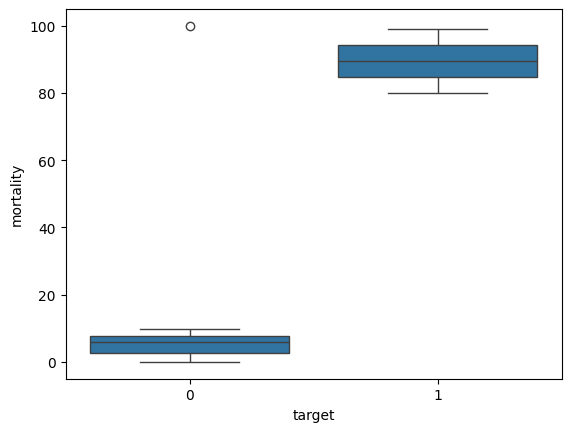

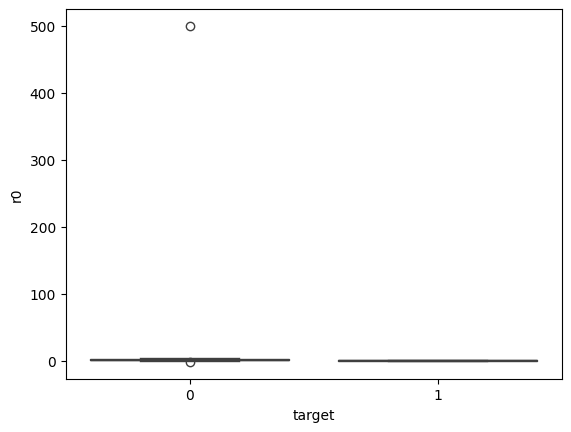

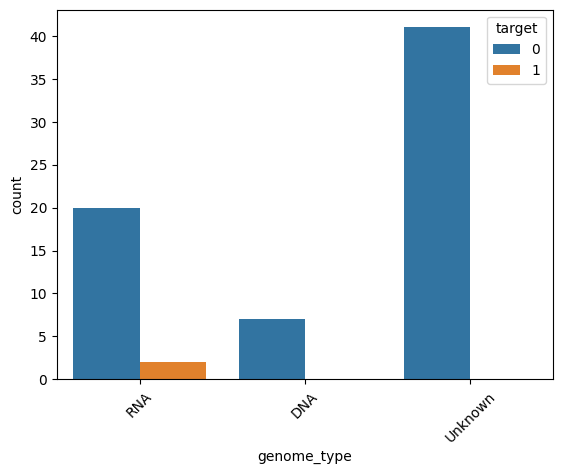

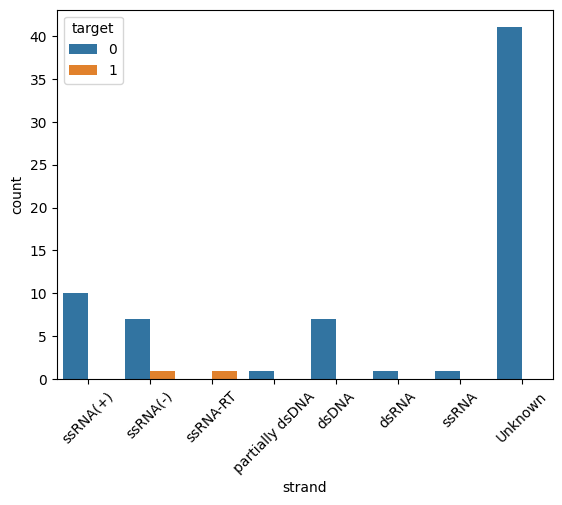

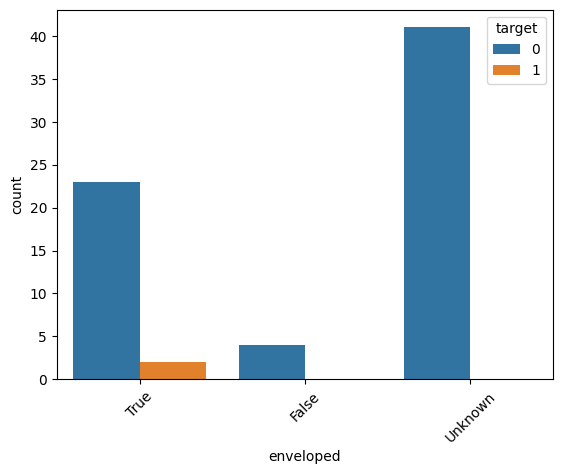

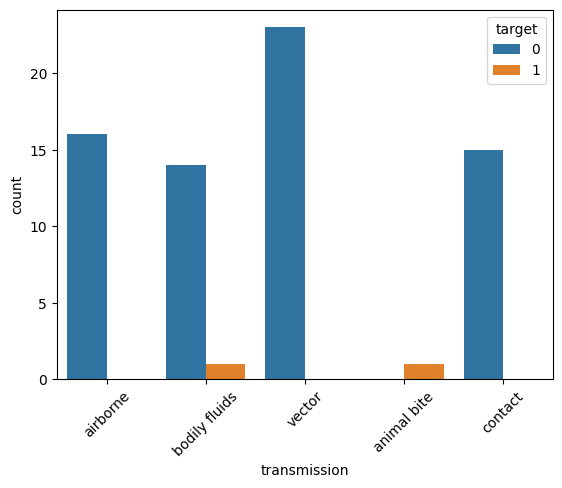

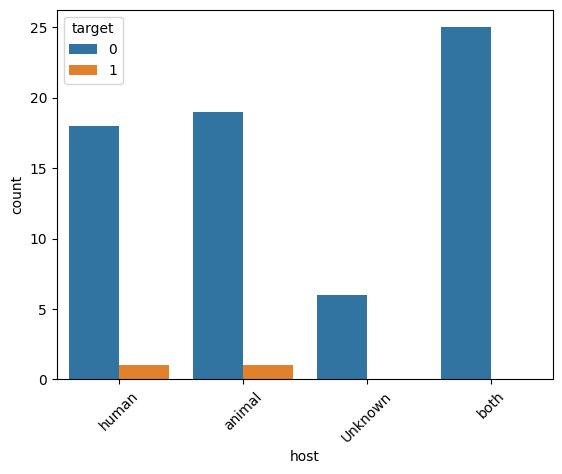

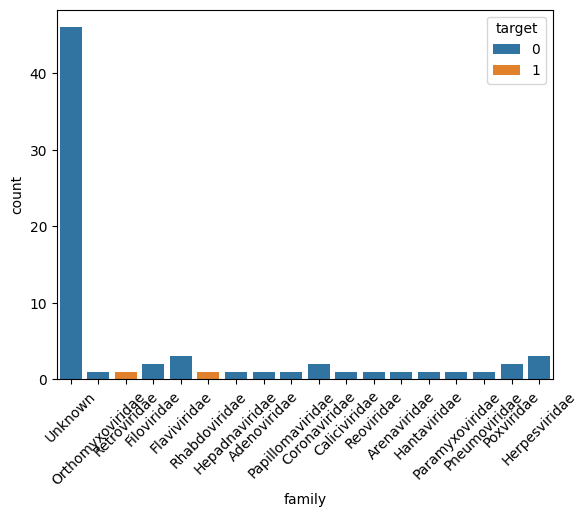

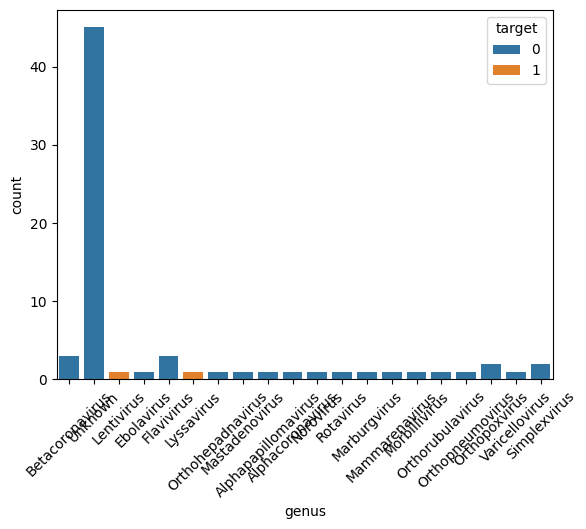

In [ ]:
# numéricas: boxplot por classe
for var in ['mortality', 'r0']:
    plt.figure()
    sns.boxplot(data=dataset_full_2, x='target', y=var)
    plt.show()

# categóricas: proporção por classe
for var in ['genome_type', 'strand', 'enveloped', 'transmission', 'host', 'family', 'genus']:
    plt.figure()
    sns.countplot(data=dataset_full_2, x=var, hue='target')
    plt.xticks(rotation=45)
    plt.show()

Os gráficos acima mostram visualmente que mortality é a única feature que separa bem as duas classes do target. Pra comprovar isso estatisticamente, vou rodar três testes que respondem perguntas diferentes:

- Mann-Whitney em mortality vs target: confirma se vírus de alto risco têm mortality maior que os outros (numérica vs categórica binária, não-paramétrico por causa do tamanho da amostra)
- Spearman entre mortality e r0: verifica se as duas numéricas são redundantes ou independentes
- Fisher's exact entre genome_type=RNA e target: testa se ser RNA tem associação com alto risco (categóricas com contagem baixa)

In [160]:
from scipy.stats import mannwhitneyu

mortality_neg = dataset_full_2[dataset_full_2['target'] == 0]['mortality']
mortality_pos = dataset_full_2[dataset_full_2['target'] == 1]['mortality']

stat, p = mannwhitneyu(mortality_pos, mortality_neg, alternative='greater')
print(f'estatística: {stat}')
print(f'p-valor: {p}')

estatística: 134.0
p-valor: 0.010450242981779372


In [161]:
from scipy.stats import spearmanr

stat, p = spearmanr(dataset_full_2['mortality'], dataset_full_2['r0'])
print(f'correlação: {stat}')
print(f'p-valor: {p}')

correlação: -0.20231209558778276
p-valor: 0.09303436301618022


In [ ]:
from scipy.stats import fisher_exact

tabela = pd.crosstab(
    dataset_full_2['genome_type'] == 'RNA',
    dataset_full_2['target']
)
print(tabela)

odds, p = fisher_exact(tabela, alternative='greater')
print(f'odds ratio: {odds}')
print(f'p-valor: {p}')

target        0  1
genome_type       
False        48  0
True         20  2
odds ratio: inf
p-valor: 0.09565217391304348


Resultados:

- Mann-Whitney (mortality vs target): p=0.0104. Significativo, comprova que vírus de alto risco têm mortality maior.
- Spearman (mortality vs r0): correlação -0.20, p=0.093. Não significativo, mortality e r0 podem ser tratadas como independentes no modelo.
- Fisher's exact (RNA vs target): p=0.096. Todos os high risk são RNA, mas o teste não chega a significância.

Os testes Spearman e Fisher não passaram, mas isso reflete o tamanho da classe positiva (n=2), que limita o poder estatístico. O padrão visual continua válido, só não consegue ser comprovado com confiança estatística. A conclusão é que mortality é o único sinal forte e comprovável do dataset.

target
0    68
1     2
Name: count, dtype: int64
target
0   0.97
1   0.03
Name: proportion, dtype: float64


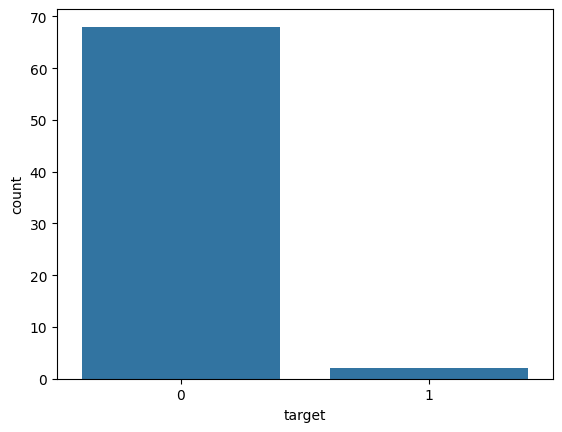

In [163]:
dataset_full_3 = dataset_full_2.drop(columns=['risk_category'])

print(dataset_full_3['target'].value_counts())
print(dataset_full_3['target'].value_counts(normalize=True))

sns.countplot(data=dataset_full_3, x='target')
plt.show()

Removi a coluna risk_category porque o target foi derivado dela, mantê-la causaria data leakage no modelo, ou seja,o modelo veria a resposta direto.

Aqui também fica claro o desbalanceamento da variável alvo e que implicará na escolha de modelagem a seguir

In [164]:
dataset_full_3

,virus_id,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host,target
0,1,Unknown,Betacoronavirus,RNA,ssRNA(+),True,airborne,2.00,2.50,human,0
1,2,Orthomyxoviridae,Unknown,RNA,ssRNA(-),True,airborne,0.10,1.30,human,0
2,3,Retroviridae,Lentivirus,RNA,ssRNA-RT,True,bodily fluids,80.00,2.00,human,1
3,4,Filoviridae,Ebolavirus,RNA,ssRNA(-),True,airborne,5.91,1.80,human,0
4,5,Unknown,Flavivirus,RNA,ssRNA(+),True,vector,0.01,3.00,human,0
5,6,Flaviviridae,Unknown,RNA,ssRNA(+),True,vector,5.91,4.00,human,0
6,7,Rhabdoviridae,Lyssavirus,RNA,ssRNA(-),True,animal bite,99.00,0.50,animal,1
7,8,Hepadnaviridae,Orthohepadnavirus,DNA,partially dsDNA,True,airborne,4.10,1.59,Unknown,0
8,9,Adenoviridae,Mastadenovirus,DNA,dsDNA,False,vector,0.23,500.00,human,0
9,10,Papillomaviridae,Alphapapillomavirus,DNA,dsDNA,False,vector,5.91,2.99,animal,0


In [165]:
dataset_full_3.to_csv('C:/Users/kened/OneDrive/Desktop/Estudos/Lean/data/processed/virus_processed.csv', index=False)